In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ehtim as eh
from tqdm.notebook import tqdm
import functools

import jax
import flax
from jax import numpy as jnp
from flax import linen as nn
from flax.training import train_state
from typing import Any, Callable
import optax
import sys
from flax.serialization import from_bytes
from flax.serialization import to_bytes

from datetime import datetime


The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.
Welcome to eht-imaging! v 1.2.10 



Loading text image:  datasets/avery_sgra_eofn.txt


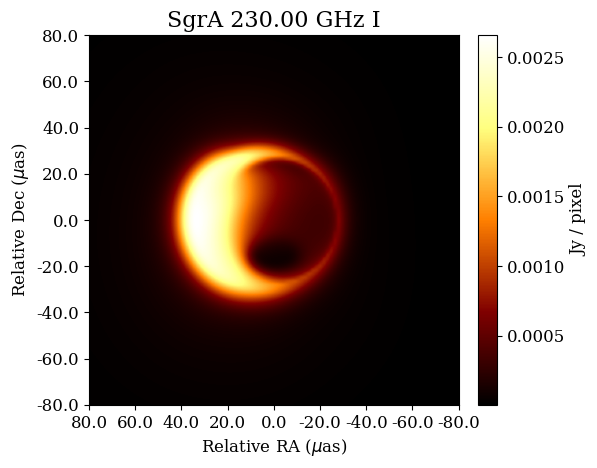

OBSERVED
Producing clean visibilities from image with nfft FT . . . 


In [2]:
image_path = 'datasets/avery_sgra_eofn.txt'
array_path = 'datasets/EHT2017.txt'
image_true = eh.image.load_txt(image_path)
array = eh.array.load_txt(array_path)

image_true.display()

tint = 5
tadv = 600
tstart_hr = 0
tstop_hr = 24

obs = array.obsdata(tint=tint, tadv=tadv, tstart=tstart_hr, tstop=tstop_hr, ra=image_true.ra, 
                    dec=image_true.dec, rf=image_true.rf, mjd=image_true.mjd,
                    bw=image_true.rf, timetype='UTC', polrep='stokes')
print("OBSERVED")

obs = image_true.observe_same_nonoise(obs) 

/tmp/ipykernel_201484/1618106342.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sc = ax.scatter(u, v, c=t, cmap=plt.cm.get_cmap(cmap), s=s)


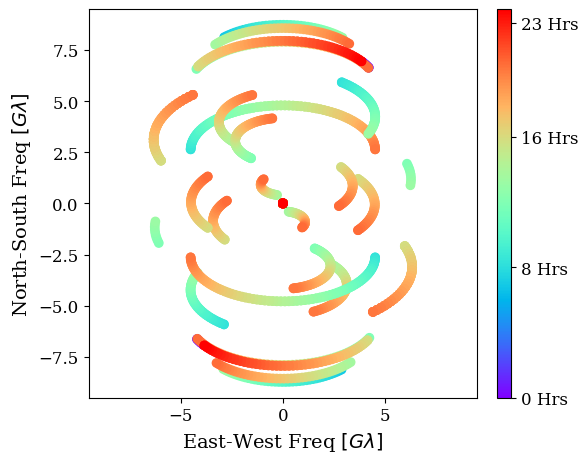

In [3]:

def plot_uv_coverage(obs, ax=None, fontsize=14, s=None, cmap='rainbow', add_conjugate=True, xlim=(-9.5, 9.5), ylim=(-9.5, 9.5),
                     shift_inital_time=True, cbar=True, cmap_ticks=[0, 4, 8, 12], time_units='Hrs'):
    """
    Plot the uv coverage as a function of observation time.
    x axis: East-West frequency
    y axis: North-South frequency

    Parameters
    ----------
    obs: ehtim.Obsdata
        ehtim Observation object
    ax: matplotlib axis,
        A matplotlib axis object for the visualization.
    fontsize: float, default=14,
        x/y-axis label fontsize.
    s: float,
        Marker size of the scatter points
    cmap : str, default='rainbow'
        A registered colormap name used to map scalar data to colors.
    add_conjugate: bool, default=True,
        Plot the conjugate points on the uv plane.
    xlim, ylim: (xmin/ymin, xmax/ymax), default=(-9.5, 9.5)
        x-axis range in [Giga lambda] units
    shift_inital_time: bool,
        If True, observation time starts at t=0.0
    cmap_ticks: list,
        List of the temporal ticks on the colorbar
    time_units: str,
        Units for the colorbar
    """
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    giga = 10**9
    u = np.concatenate([obsdata['u'] for obsdata in obs.tlist()]) / giga
    v = np.concatenate([obsdata['v'] for obsdata in obs.tlist()]) / giga
    t = np.concatenate([obsdata['time'] for obsdata in obs.tlist()])

    if shift_inital_time:
        t -= t.min()

    if add_conjugate:
        u = np.concatenate([u, -u])
        v = np.concatenate([v, -v])
        t = np.concatenate([t, t])

    if ax is None:
        fig, ax = plt.subplots(1, 1)
    else:
        fig = ax.get_figure()

    if time_units == 'mins':
        t *= 60.0
        
    sc = ax.scatter(u, v, c=t, cmap=plt.cm.get_cmap(cmap), s=s)
    ax.set_xlabel(r'East-West Freq $[G \lambda]$', fontsize=fontsize)
    ax.set_ylabel(r'North-South Freq $[G \lambda]$', fontsize=fontsize)
    ax.invert_xaxis()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    
    if cbar is True:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='3.5%', pad=0.2)
        cbar = fig.colorbar(sc, cax=cax, ticks=cmap_ticks)
        cbar.set_ticklabels(['{} {}'.format(tick, time_units) for tick in cbar.get_ticks()])
    plt.tight_layout()

plot_uv_coverage(obs, cmap_ticks=[0, 8, 16, 23])

In [4]:
def shard(xs):
    """Split data into shards for multiple devices along the first dimension."""
    return jax.tree_util.tree_map(lambda x: x.reshape((jax.local_device_count(), -1) + x.shape[1:]), xs)

def flattened_traversal(fn):
    def mask(data):
        flat = flax.traverse_util.flatten_dict(data)
        return flax.traverse_util.unflatten_dict({k: fn(k, v) for k, v in flat.items()})
    return mask

class MLP(nn.Module): 
    net_depth: int = 4 
    net_width: int = 128
    activation: Callable[..., Any] = nn.relu 
    out_channel: int = 1 
    do_skip: bool = True 
  
    @nn.compact 
    def __call__(self, x):
        """A simple Multi-Layer Preceptron (MLP) network

        Parameters
        ----------
        x: jnp.ndarray(float32), 
            [batch_size * n_samples, feature], points.
        net_depth: int, 
            the depth of the first part of MLP.
        net_width: int, 
            the width of the first part of MLP.
        activation: function, 
            the activation function used in the MLP.
        out_channel: 
            int, the number of alpha_channels.
        do_skip: boolean, 
            whether or not to use a skip connection

        Returns
        -------
        out: jnp.ndarray(float32), 
            [batch_size * n_samples, out_channel].
        """
        dense_layer = functools.partial(
            nn.Dense, kernel_init=jax.nn.initializers.he_uniform()) 

        if self.do_skip:
            skip_layer = self.net_depth // 2 


        inputs = x
        for i in range(self.net_depth): 
            x = dense_layer(self.net_width)(x) 
            x = self.activation(x) 
            if self.do_skip:
                if i % skip_layer == 0 and i > 0:
                    x = jnp.concatenate([x, inputs], axis=-1) 
        out = dense_layer(self.out_channel)(x) 

        return out


def posenc(x, deg):
    """
    Concatenate `x` with a positional encoding of `x` with degree `deg`.
    Instead of computing [sin(x), cos(x)], we use the trig identity
    cos(x) = sin(x + pi/2) and do one vectorized call to sin([x, x+pi/2]).

    Parameters
    ----------
    x: jnp.ndarray, 
        variables to be encoded. Note that x should be in [-pi, pi].
    deg: int, 
        the degree of the encoding.

    Returns
    -------
    encoded: jnp.ndarray, 
        encoded variables.
    """
    if deg == 0:
        return x
    scales = jnp.array([2**i for i in range(deg)]) 
    xb = jnp.reshape((x[..., None, :] * scales[:, None]),
                     list(x.shape[:-1]) + [-1]) 
    four_feat = safe_sin(jnp.concatenate([xb, xb + 0.5 * jnp.pi], axis=-1))
    return jnp.concatenate([x] + [four_feat], axis=-1) 

class NeuralImage(nn.Module):
    """
    Full function to predict emission at a time step.
    
    Parameters
    ----------
    posenc_deg: int, default=3
    net_depth: int, default=4
    net_width: int, default=128
    activation: Callable[..., Any], default=nn.relu
    out_channel: int default=1
    do_skip: bool, default=True
    """
    posenc_deg: int = 3
    net_depth: int = 4
    net_width: int = 128
    activation: Callable[..., Any] = nn.relu
    out_channel: int = 1
    do_skip: bool = True
    
    @nn.compact
    def __call__(self, coords):
        image_MLP = MLP(self.net_depth, self.net_width, self.activation, self.out_channel, self.do_skip)
        def predict_image(coords):
            net_output = image_MLP(posenc(coords, self.posenc_deg))
            image = nn.sigmoid(net_output[..., 0] - 10.) 
            return image
        return predict_image(coords)
    
safe_sin = lambda x: jnp.sin(x % (100 * jnp.pi))

In [5]:
def loss_fn(params, predictor_fn, target, A, sigma, coords):
    '''
    Args:
        params: pytree (nested dict) of all of the model's weights and biases. 
        predictor_fn: the model's apply function
        target: measured intensities
        A: measurement matrix
        sigma: Thermal noise per visibility
        coords: array of shape (N_pixels, 2) with all (x,y) grid coords
    
    Returns:
        image: predicted intensities -> image
        loss: 
    '''
    image = predictor_fn({'params': params}, coords) # evanluate the neural image model at each (x, y)
    vis = jnp.matmul(A, image.ravel()) # return a view (no copy) if possible of image as a 1D array -> 
    loss = jnp.mean((jnp.abs(vis - target))**2)
    return loss, [image]

@jax.jit
def train_step(state, target, A, sigma, coords):
    (loss, [image]), grads = jax.value_and_grad(loss_fn, argnums=(0), has_aux=True)(state.params, state.apply_fn, target, A, sigma, coords)
    grads = jax.lax.pmean(grads, axis_name='batch')
    state = state.apply_gradients(grads=grads)
    return loss, state, image

predictor = NeuralImage()
train_pstep = jax.pmap(train_step, axis_name='batch', in_axes=(0, 0, 0, 0, None))
print(jax.local_device_count())

4


In [6]:
"""
Run optimization. Note that this requieres tensorboard and tensorboardX for logging.
To remove tensorboard logging comment out the lines with # logging
"""

target = obs.data['vis']

npix = 100
fov = 1*image_true.fovx()
prior = eh.image.make_square(obs, npix, fov)
vis, sigma, A = eh.imaging.imager_utils.chisqdata_vis(obs, prior, mask=[])
sigma = jnp.ones_like(sigma)
x, y = np.linspace(0, 1, prior.xdim), np.linspace(0, 1, prior.ydim)
coords = np.moveaxis(np.array(np.meshgrid(x, y, indexing='ij')), 0, -1)

hparams = {'num_iters': 10000, 'lr_init': 1e-3, 'lr_final': 1e-5, 'batchsize': 512}
params = predictor.init(jax.random.PRNGKey(1), coords)['params']
tx = optax.adam(learning_rate=optax.polynomial_schedule(hparams['lr_init'], hparams['lr_final'], 1, hparams['num_iters']))
state = train_state.TrainState.create(apply_fn=predictor.apply, params=params, tx=tx)  

state = flax.jax_utils.replicate(state)
for i in tqdm(range(hparams['num_iters']), desc='iteration'):
    batch = np.random.choice(range(len(target)), hparams['batchsize'], replace=False)
    loss, state, image = train_pstep(state, shard(target[batch, ...]), shard(A[batch, ...]), shard(sigma[batch, ...]), coords)
    # loss, state, image = train_step(state, target[batch, ...], A[batch, ...], sigma[batch, ...], coords)
    if i % 1000 == 0:
        print(np.mean(loss))

state = jax.device_get(flax.jax_utils.unreplicate(state))


iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

0.70257723
0.0002061734
1.0490279e-05
1.9258627e-05
0.00010445327
0.00023093238
2.61948e-05
7.0905253e-06
4.901753e-06
3.4858285e-06


In [6]:
fname = 'bh_vlbi_params.msgpack'
template = NeuralImage()
with open(fname, "rb") as fp:  
    data = fp.read()  
params = from_bytes(template, data)

npix = 100
fov = 1*image_true.fovx()
prior = eh.image.make_square(obs, npix, fov)
vis, sigma, A = eh.imaging.imager_utils.chisqdata_vis(obs, prior, mask=[])
x, y = np.linspace(0, 1, prior.xdim), np.linspace(0, 1, prior.ydim)
coords = np.moveaxis(np.array(np.meshgrid(x, y, indexing='ij')), 0, -1)

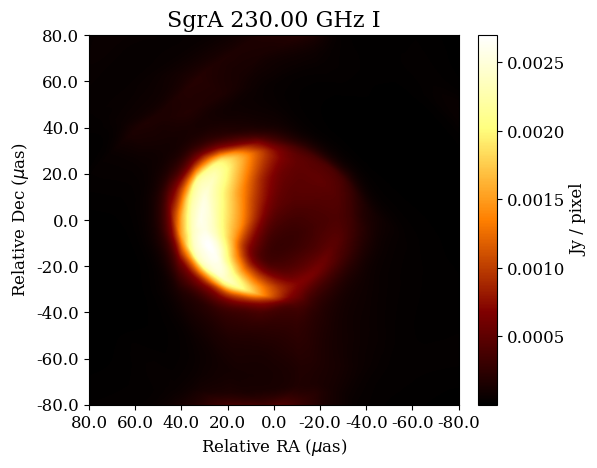

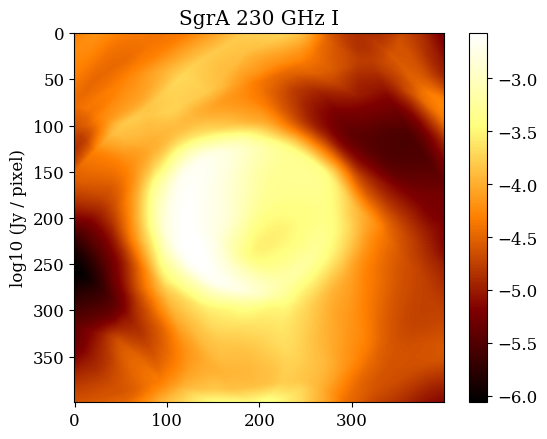

In [7]:
### training result
npix = 400
image_rec = eh.image.make_square(obs, npix, fov)
x, y = np.linspace(0, 1, image_rec.xdim), np.linspace(0, 1, image_rec.ydim)
coords = np.moveaxis(np.array(np.meshgrid(x, y, indexing='ij')), 0, -1)
image_data = predictor.apply({'params': params}, coords)
image_rec.imvec = image_data.ravel()

image_rec.display()
plt.figure()
plt.title('SgrA 230 GHz I')
plt.imshow(jnp.log10(image_rec.imarr()), cmap='afmhot')
plt.ylabel('log10 (Jy / pixel)')
plt.colorbar()
plt.savefig('bh_vlbi_unc_results/bh_vlbi_pred_log_scaled.png')



In [8]:
npix = 100
nvis = vis.shape[0]
print(nvis)
image_rec = eh.image.make_square(obs, npix, fov)
xdim = image_rec.xdim
ydim = image_rec.ydim
x, y = np.linspace(0, 1, xdim), np.linspace(0, 1, ydim)
coords = np.moveaxis(np.array(np.meshgrid(x, y, indexing='ij')), 0, -1)

1030


In [9]:
def bilinear(coords, theta):
    """gpt generated function to fill in for now"""
    gx, gy, _ = theta.shape
    # scale to vertex index space
    x = coords[..., 0] * (gx - 1)
    y = coords[..., 1] * (gy - 1)

    i0 = jnp.floor(x).astype(jnp.int32)
    j0 = jnp.floor(y).astype(jnp.int32)
    i1 = jnp.clip(i0 + 1, 0, gx - 1)
    j1 = jnp.clip(j0 + 1, 0, gy - 1)

    wx = x - i0
    wy = y - j0

    # gather four corners
    t00 = theta[i0, j0] # lower-left
    t10 = theta[i1, j0] # lower-right
    t01 = theta[i0, j1] # upper-left
    t11 = theta[i1, j1] # upper-right

    return ((1 - wx) * (1 - wy))[..., None] * t00 + \
           (wx * (1 - wy))[..., None] * t10 + \
           ((1 - wx) * wy)[..., None] * t01 + \
           (wx * wy)[..., None] * t11

class DeformationGrid(nn.Module):
    resolution: tuple[int, ...]

    @nn.compact
    def __call__(self, coords):
        theta = self.param(
            'theta', 
            nn.initializers.zeros, 
            self.resolution + (coords.shape[-1],)
        )
        return bilinear(coords, theta)

def forward_with_deform(params_img, params_def, coords, predictor_fn):
    offsets = DeformationGrid.apply({'params': params_def}, coords)
    image = predictor_fn.apply({'params': params_img}, coords + offsets)
    return jnp.matmul(A, image.ravel())

In [10]:
grid_res = (64, 64)
P = 2 * grid_res[0] * grid_res[1] #the number of parameters in the grid
def_grid = DeformationGrid(grid_res)

# freeze parameters 
params_img = params
params_img_frozen = jax.tree_util.tree_map(jnp.array, params_img)

params_def = def_grid.init(
    jax.random.PRNGKey(0), 
    jnp.array([[0, 0]]))['params']
params_def = jax.tree_util.tree_map(jnp.zeros_like, params_def)

In [11]:
def _dense_banded_from_Js(Js, nx, ny, nvis, lam, band_level=1, include_cross=True):
    """Return a dense banded proxy H_b = (J^T J)/nvis with selected offsets (+-x, +-y, etc.) plus ridge."""
    P = Js.shape[1]
    H = jnp.diag(jnp.sum(Js * Js, axis=0) / nvis)

    def add_band(off, mask):
        P = Js.shape[1]
        v = jnp.sum(Js[:, :P-off] * Js[:, off:], axis=0) / nvis
        v = v * mask
        i = jnp.arange(P-off)
        H_off = jnp.zeros_like(H).at[i, i+off].set(v).at[i+off, i].set(v)
        return H + H_off

    def mask(nx, ny, P, off):
        i = jnp.arange(P - off)
        v1 = i // 2; x1 = v1 % nx; y1 = v1 // nx
        v2 = (i + off) // 2; x2 = v2 % nx; y2 = v2 // nx
        return (jnp.abs(x2-x1) <= 1) & (jnp.abs(y2-y1) <= 1)

    if include_cross:
        H = add_band(1, jnp.ones(Js.shape[1]-1, dtype=bool))

    H = add_band(2, mask(nx, ny, P, 2))
    H = add_band(2*nx, mask(nx, ny, P, 2*nx))

    if band_level >= 2:
        H = add_band(4, mask(nx, ny, P, 4))
        H = add_band(4*nx, mask(nx, ny, P, 4*nx))

    H = H + 2.0*lam*jnp.eye(P)
    return H

def _kfac_kron_dense_from_Js(Js, nx, ny, nvis, lam, use_channel_cov=True):
    P = Js.shape[1]
    Js4 = Js.reshape(Js.shape[0], ny, nx, 2)

    Ky = jnp.tensordot(Js4, Js4, axes=([0,2,3],[0,2,3])) / nvis
    Kx = jnp.tensordot(Js4, Js4, axes=([0,1,3],[0,1,3])) / nvis
    if use_channel_cov:
        C = jnp.tensordot(Js4, Js4, axes=([0,1,2],[0,1,2])) / nvis
    else:
        C = jnp.eye(2)

    Hk = jnp.kron(jnp.kron(Ky, Kx), C)
    H = Hk + 2.0*lam*jnp.eye(P)
    return H

def laplacian_diag_2ch(nx, ny):
    deg = jnp.full((ny, nx), 4.0)
    deg = deg.at[0, :].set(3.0)
    deg = deg.at[-1, :].set(3.0)
    deg = deg.at[:, 0].set(3.0)
    deg = deg.at[:, -1].set(3.0)
    deg = deg.at[0, 0].set(2.0)
    deg = deg.at[0, -1].set(2.0)
    deg = deg.at[-1, 0].set(2.0)
    deg = deg.at[-1, -1].set(2.0)
    v = deg.ravel()
    return jnp.repeat(v, 2)

def _split_2ch_interleaved(vec, NX, NY):
    vv = vec.reshape(NX*NY, 2)
    VX = vv[:, 0].reshape(NX, NY)
    VY = vv[:, 1].reshape(NX, NY)
    return VX, VY

def _merge_2ch_interleaved(VX, VY):
    NX, NY = VX.shape
    vv = jnp.stack([VX.reshape(-1), VY.reshape(-1)], axis=1)
    return vv.reshape(-1)

def _laplacian_eigs_fft(NX, NY):
    kx = jnp.arange(NX)
    ky = jnp.arange(NY)
    lam_x = 4.0 * jnp.sin(jnp.pi * kx / NX)**2
    lam_y = 4.0 * jnp.sin(jnp.pi * ky / NY)**2
    return lam_x[:, None] + lam_y[None, :]  # (NX, NY)

def _normalize_rowblocks(Js):
    """
    Optional: after sigma-scaling, normalize each 2-row (Re/Im) block to unit Frobenius norm.
    Js: (2N, P)
    """
    nb = Js.shape[0] // 2
    Js2 = Js.reshape(nb, 2, -1)
    norms = jnp.linalg.norm(Js2, axis=(1, 2), keepdims=True) + 1e-12
    Js2 = Js2 / norms
    return Js2.reshape(-1, Js.shape[1])


def _spectral_diag_variance_from_Fdiag(F_diag, NX, NY, lam_w, lam_s, eps=1e-12):
    """
    Take data Fisher diagonal F_diag (length P), apply Laplacian prior in Fourier basis,
    and return a per-parameter variance vector V_spec (length P).
    """
    FX, FY = _split_2ch_interleaved(F_diag, NX, NY)

    FhatX = jnp.fft.fft2(FX)
    FhatY = jnp.fft.fft2(FY)

    Lam = _laplacian_eigs_fft(NX, NY)

    # spectral curvature (elementwise): F̂ + 2λ + 2λ_s Λ
    # take real parts in case of tiny numerical imag noise
    denomX = jnp.real(FhatX) + 2.0 * lam_w + 2.0 * lam_s * Lam
    denomY = jnp.real(FhatY) + 2.0 * lam_w + 2.0 * lam_s * Lam

    # guard against negatives (shouldn’t happen with reasonable λ, λ_s)
    denomX = jnp.maximum(denomX, eps)
    denomY = jnp.maximum(denomY, eps)

    # spectral variances, then back to pixel space
    VhatX = 1.0 / denomX
    VhatY = 1.0 / denomY
    VX = jnp.real(jnp.fft.ifft2(VhatX))
    VY = jnp.real(jnp.fft.ifft2(VhatY))

    # ensure positivity
    VX = jnp.clip(VX, a_min=0.0)
    VY = jnp.clip(VY, a_min=0.0)

    # return interleaved variance vector (length P)
    return _merge_2ch_interleaved(VX, VY)

In [12]:
NX, NY = grid_res
def forward_visibility(params_def, coords):
    """
    add offset and get updated visibility matrix
    """
    offsets = def_grid.apply({'params': params_def}, coords)
    image = predictor.apply({'params': params_img_frozen}, coords + offsets)
    return jnp.matmul(A, image.ravel())

# compute derivatives of real and imaginary parts independently--otherwise H not differentiable
def re_vis(params_def, k):
    """Re(eps_theta(r))"""
    return jnp.real(forward_visibility(params_def, coords)[k])

def im_vis(params_def, k):
    """Im(eps_theta(r))"""
    return jnp.imag(forward_visibility(params_def, coords)[k])

#take the gradient of a forward_visibility (real or imaginary) over k visibilities
def flatten(tree):
    return jnp.concatenate([t.ravel() for t in jax.tree_util.tree_leaves(tree)])

def grad_row(fn, k):
    g_tree = jax.grad(fn)(params_def, k)
    return flatten(g_tree['theta'])

# compute hessian in chunks
@functools.partial(jax.jit, static_argnums=(1,))
def chunk(idx, fn, sigma_batch):
    J = jax.vmap(lambda k: grad_row(fn, k))(idx) # evaluate grad_row over each i \in idx
    J = J.reshape((J.shape[0], -1))
    J = J / (sigma_batch[:, None] / jnp.sqrt(2))
    return J.T @ J

def fisher_sum(chunk_size, P, nvis):
    """
    Can no longer assume sigma^2 = 1/2 or use abs in loss fn. Take the derivative of the real and imaginary parts
    and compute in chunks of rows to avoid OOM. 
    
    Args:
        chunk_size: number of rows of the jacobian to evaluate in one step
        res: grid resolution, (xdim, ydim); 2D for now
    Returns:
        J_sq: = sum( (J_re_n^2 + J_im_n^2) / sigma_n^2)
    """
    #J_sq = jnp.zeros((res[0], res[1], 2))
    H = jnp.zeros((P, P))
    for start in tqdm(range(0, nvis, chunk_size), desc='iteration'):
        end = min(start+chunk_size, nvis)
        idx = jnp.arange(start, end)
        H += chunk(idx, re_vis, sigma[idx])+chunk(idx, im_vis, sigma[idx])
    return H

@functools.partial(jax.jit, static_argnums=(1,))
def chunk_diag(idx, fn, sigma_batch):
    J = jax.vmap(lambda k: grad_row(fn, k))(idx)
    J = J.reshape((J.shape[0], -1))
    J = J / (sigma_batch[:, None] / jnp.sqrt(2))
    return jnp.sum(J**2, axis=0)

def fisher_sum_diag(chunk_size, P, nvis):
    """
    Can no longer assume sigma^2 = 1/2 or use abs in loss fn. Take the derivative of the real and imaginary parts
    and compute in chunks of rows to avoid OOM. 
    
    Args:
        chunk_size: number of rows of the jacobian to evaluate in one step
        res: grid resolution, (xdim, ydim); 2D for now
    Returns:
        J_sq: = sum( (J_re_n^2 + J_im_n^2) / sigma_n^2)
    """
    #J_sq = jnp.zeros((res[0], res[1], 2))
    H = jnp.zeros((P,))
    for start in tqdm(range(0, nvis, chunk_size), desc='iteration'):
        end = min(start+chunk_size, nvis)
        idx = jnp.arange(start, end)
        H += chunk_diag(idx, re_vis, sigma[idx])+chunk_diag(idx, im_vis, sigma[idx])
    return H


@functools.partial(jax.jit, static_argnums=(1,2))
def _grad_block(idx, fn, chunk):
    @jax.checkpoint
    def one(k):
        g = jax.grad(lambda p: fn(p, k))(params_def)
        return flatten(g['theta'])
    return jax.vmap(one)(idx)

def build_J_scaled(params_def, nvis, sigma, block=32):
    pieces = []
    for start in range(0, nvis, block):
        idx = jnp.arange(start, min(start+block, nvis))
        pieces.append(_grad_block(idx, re_vis, block))
    for start in range(0, nvis, block):
        idx = jnp.arange(start, min(start+block, nvis))
        pieces.append(_grad_block(idx, im_vis, block))
    Js = jnp.concatenate(pieces, axis=0)
    sigma_big = jnp.concatenate([sigma, sigma], 0)
    return Js / (sigma_big[:, None] / jnp.sqrt(2))


def woodbury_diag(Js, lam):
    """
    Diagonal of H^{-1} using the Woodbury identity
    Js : (2N, P)   row‑scaled Jacobian
    lam: scalar    same λ that multiplies the ridge term 2λ I
    """
    lam2 = 2.0 * lam
    a_inv = 1.0 / lam2

    JJt = (Js @ Js.T)/nvis
    B = jnp.eye(JJt.shape[0]) + (1/lam2) * JJt
    B_inv = jnp.linalg.inv(B)

    diag_term = jnp.sum(Js * (B_inv @ Js), axis=0)
    V_diag = a_inv - (a_inv**2) * diag_term
    return V_diag


def compute_hessian_and_uncertainty(chunk_size: int, P, lam: float, method: str, lam_s: int = 0):
    '''
    Args:
        chunk_size (int): how many rows of the hessian to compute at a time. This is deterministic
        not approximated
        lam (float): laplace regularizer
        method (str): 
            'approx': bayes rays' implementation, never build full hessian
            'direct': build full hessian, invert, keep only diagonal of covariance matrix
            '': build full hessian, invert, keep full covariance matrix
    Returns:
        (jnp.ndarray shape (P, P), jnp.ndarray shape(nvis, nvis))
    '''
    
    if method == "approx":
        H = fisher_sum_diag(chunk_size, P, nvis)
        print('lambda:', lam)
        print(H.min(), H.max(), jnp.median(H))
        H = H/nvis + 2*lam
        V = 1/H
        print(V.min(), V.max())

        return H, V, lam
    elif method == "woodbury":
        Js = build_J_scaled(params_def, nvis, sigma)
        #Js = _normalize_rowblocks(Js)
        f_diag = jnp.sum(Js**2, axis=0)
        print(f_diag.min(), f_diag.max())
        #lam = 0.5*0.02*jnp.median(f_diag)
        #print('lambda:', lam)
        V_diag = woodbury_diag(Js, lam)
        print(V_diag.min(), V_diag.max())
        return None, V_diag, lam
    elif method in ("band1", "band2"):
        # 1 or 2-ring banded Hessian with a tiny Neumann inverse-diagonal
        Js = build_J_scaled(params_def, nvis, sigma)
        H = _dense_banded_from_Js(Js, NX, NY, nvis, lam,
                                  band_level=(1 if method=="band1_full" else 2),
                                  include_cross=True)
        V = jnp.linalg.inv(H)
        return H, V, lam

    elif method == "kron":   
        # KFAC-ish Kronecker diagonal
        Js = build_J_scaled(params_def, nvis, sigma)
        H = _kfac_kron_dense_from_Js(Js, NX, NY, nvis, lam, use_channel_cov=True)
        V = jnp.linalg.inv(H)
        return H, V, lam
    elif method == "approx_laplace_smooth":
        F_diag = fisher_sum_diag(chunk_size, P, nvis) / nvis
        Ldiag = laplacian_diag_2ch(NX, NY)
        H_diag = F_diag + 2.0 * lam * F_diag + 2*lam_s * Ldiag
        V_diag = 1.0 / (H_diag + 1e-12)
        return H_diag, V_diag, lam
    elif method == "approx_spectral_prior":
        F_diag = fisher_sum_diag(chunk_size, P, nvis) / nvis
        med = jnp.median(F_diag)
        lam_w_eff = lam if lam > 0 else 1e-2 * med
        lam_s_eff = lam_s if lam_s > 0 else 1e-3 * med
        V_diag = _spectral_diag_variance_from_Fdiag(F_diag, NX, NY, lam_w_eff, lam_s_eff)
        return F_diag, V_diag, lam_w_eff
    else:
        H = fisher_sum(chunk_size, P, nvis)
        #lam = 0.5*0.02*jnp.median(jnp.diag(H))
        print('lambda:', lam)
        
        H = H/nvis + 2.0*lam*jnp.eye(P)
        d = jnp.diag(H)
        print(d.min(), d.max())
        print("cond(H)          :", jnp.linalg.cond(H))

        V = jnp.linalg.inv(H)
        print(V.min(), V.max())
        if method == "direct":
            V = jnp.diag(V)
    return H, V, lam

In [13]:

diagonal = "approx"
H, V, lam= compute_hessian_and_uncertainty(chunk_size=10, P=P, lam=1e-1/(grid_res[0]**2), method=diagonal, lam_s = 1e-4/(64**2))
print(jnp.max(jnp.log10(V)))


iteration:   0%|          | 0/103 [00:00<?, ?it/s]

lambda: 2.44140625e-05
0.0009052162 68631230.0 3502.3706
1.5007747e-05 20117.9
4.3035827


In [22]:
print(V.ndim)
print(V.shape)

1
(8192,)


In [ ]:
gx, gy = grid_res
def flat_idx(i, j, channel): # channel=0(x) or 1(y)
    return 2 * (i*gy + j) + channel

@jax.jit
def build_W_and_idx(u):
    """
    Build the bilinear weight matrix and neighboring weight indicies for effective batching so we dont OOM
    Note that the batching is deterministic. 
    """
    ux, uy = u
    x = ux * (gx-1)
    y = uy * (gy-1)
    i0, j0 = jnp.floor(x).astype(int), jnp.floor(y).astype(int)
    i1, j1 = jnp.minimum(i0+1, gx-1), jnp.minimum(j0+1, gy-1)
    wx, wy = x - i0, y - j0

    # four vertex weights
    w  = jnp.array([
        (1-wx)*(1-wy),
        wx *(1-wy),
        (1-wx)*wy,
        wx *wy,
    ])
    idx = jnp.array([
        flat_idx(i0,j0,0), flat_idx(i0,j0,1),
        flat_idx(i1,j0,0), flat_idx(i1,j0,1),
        flat_idx(i0,j1,0), flat_idx(i0,j1,1),
        flat_idx(i1,j1,0), flat_idx(i1,j1,1),
    ]) # length-8

    #sigma_sub = V[idx[:,None], idx[None,:]]  # (8,8) sub matrix of neighboring bilinear interpolation weights
    W = jnp.stack([ # 2×8
        jnp.reshape(jnp.repeat(w,2)[0::2], (4,)), # x-weights
        jnp.reshape(jnp.repeat(w,2)[1::2], (4,)), # y-weights
    ], axis=0).repeat(2, axis=1)[:,:8]
    
    return idx, W
    '''C = W @ sigma_sub @ W.T
    return jnp.sqrt(jnp.trace(C))'''
def W_from_weights(w):  # w = (w00, w10, w01, w11)
    return jnp.array([
        [w[0], 0.0,  w[1], 0.0,  w[2], 0.0,  w[3], 0.0],   # x-channel
        [0.0, w[0],  0.0, w[1],  0.0, w[2],  0.0, w[3]],   # y-channel
    ])

def make_unc_fn(Sigma):
    """
    Function to handle both a diagonal and full hessian computation.
    Later, we compare the diagonal with the full hessian.
    """
    is_diag = Sigma.ndim==1

    @jax.jit
    def pixel_sigma(u):
        idx, W = build_W_and_idx(u)
        
        if is_diag:
            sigma_sub = jnp.diag(Sigma[idx])
        else:
            sigma_sub = Sigma[idx[:,None], idx[None,:]]
        return jnp.sqrt(jnp.trace(W @ sigma_sub @ W.T))
    return pixel_sigma

# vectorise over pixels in manageable chunks
def sigma_map_from_coords(coords, Sigma, chunk=8192):
    """
    compute the full uncertainty map from bayes rays, evaluating at 
    each point in coords
    """
    c_flat = coords.reshape(-1,2)
    unc_fn = make_unc_fn(Sigma)
    out = []
    for k in range(0, c_flat.shape[0], chunk):
        out.append(jax.vmap(unc_fn)(c_flat[k:k+chunk]))
    return jnp.concatenate(out).reshape(coords.shape[:2])

def plot_uncertainty_figs(sigma_map, log_scaled: bool, save_fig: bool, npix: int=100, parent_dir: str='', ):
    """Plot the recovered uncertainty, the network's predicted image (log scaled), and the network's predicted image (not log scaled) """
    fig, axes = plt.subplots(1, 3, figsize=(20,10))

    image_rec = eh.image.make_square(obs, npix, fov)
    x, y = np.linspace(0, 1, image_rec.xdim), np.linspace(0, 1, image_rec.ydim)
    coords = np.moveaxis(np.array(np.meshgrid(x, y, indexing='ij')), 0, -1)
    image_data = predictor.apply({'params': params}, coords)
    image_rec.imvec = image_data.ravel()
    
    image_rec.display(scale='log', axis=axes[1])
    image_rec.display(axis=axes[2])
    axes[1].set_title('Predicted Image (log10 scaled)')
    axes[2].set_title('Predicted Image')
    
    if log_scaled:
        im1 = axes[0].imshow(jnp.log10(sigma_map+1e-14), cmap='plasma', origin="upper")
        axes[0].set_title(f"Uncertainty map (log scaled)\ngrid res={grid_res}, diagonal={'None' if not diagonal else diagonal}")
    else: 
        p98 = jnp.percentile(sigma_map, 98)
        p2 = jnp.percentile(sigma_map, 2)
        im1 = axes[0].imshow(sigma_map, vmin=p2, vmax=p98, cmap='plasma', origin="upper")
        axes[0].set_title(f"Uncertainty map (2th-98th percentile)\ngrid res={grid_res}\n, diagonal={'None' if not diagonal else diagonal}")
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(axes[0])
    cax = divider.append_axes("right", size="5%", pad=0.2)
    fig.colorbar(im1, cax=cax)
    plt.tight_layout()
    if save_fig:
        plt.savefig(f'{parent_dir}/logscaled_grid_res{grid_res[0]}x{grid_res[1]}_diagonal{diagonal}_lambda{lam}_posenc{3}_clip.png')
    plt.show()

    return sigma_map


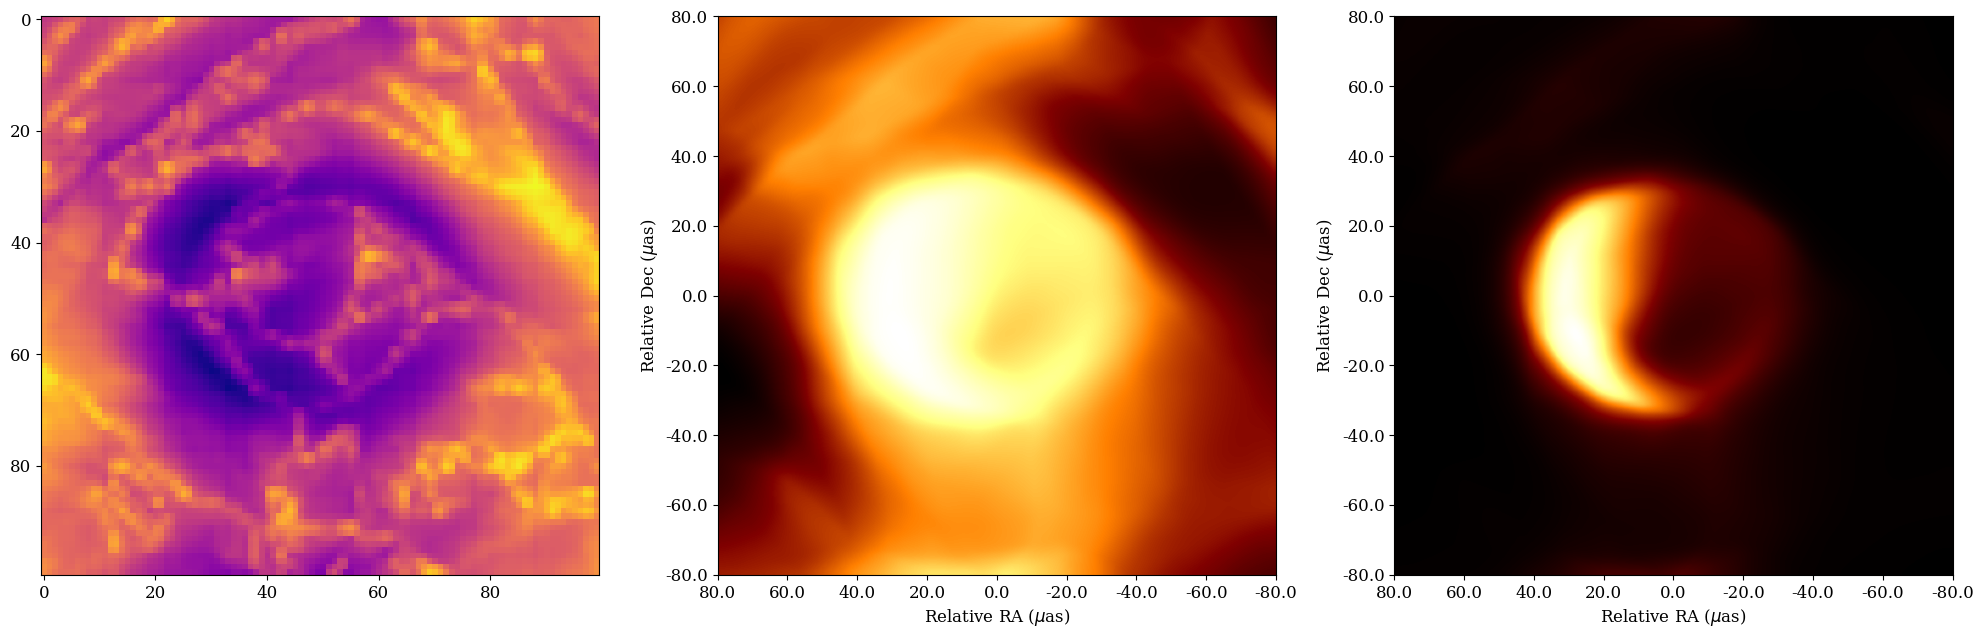

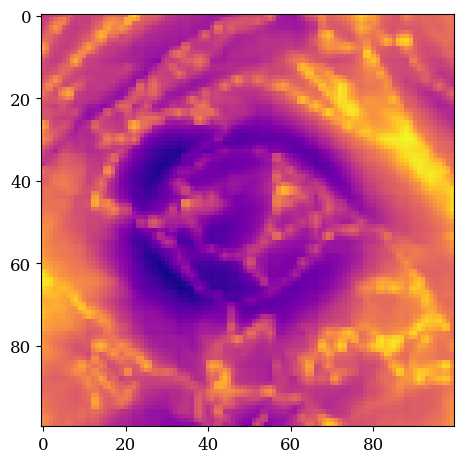

In [ ]:
# bilinear upsample
grid_coords = np.stack(np.meshgrid(np.linspace(0, 1, gx), np.linspace(0, 1, gy), indexing='xy'), axis=-1)
sigma_map = sigma_map_from_coords(grid_coords, V).reshape(gx, gy)
sigma_map = bilinear(coords[..., ::-1], sigma_map[..., None]).squeeze(-1)

plot_uncertainty_figs(sigma_map, log_scaled=True, save_fig=False, parent_dir='')
print()

In [ ]:
print(float(sigma.min()), float(sigma.max()))
print(H.shape)
F_diag = H - (2*jnp.mean(H)*0.01)
print(np.count_nonzero(F_diag>1e-12))
print(np.count_nonzero(F_diag<1e-12))
print(jnp.median(H))
print(jnp.mean(H))
print("mean fisher", float(F_diag.mean()), "prior:", 2*jnp.mean(H)*0.01)

0.0002659736923655093 0.0082653835275846


AttributeError: 'NoneType' object has no attribute 'shape'